# Prueba de Progreso 3: Competición de datos — Predicción del daño de terremotos
**Asignatura:** Técnicas de Aprendizaje Automático 2026 — UCLM  
**Alumno:** Oussama Bolbaroud

---

|| datos |
|---|---|
| **Usuario DrivenData** | `coco_26` |
| **Posición en el ranking** | *1059* |
| **Mejor micro F1 score** | *0.7422* |

---

## 1. Introducción y contexto

El objetivo es predecir el **nivel de daño** (`damage_grade`) sufrido por edificios en Nepal tras el terremoto de Gorkha de 2015. Es un problema de **clasificación ordinal multiclase** con 3 categorías:
- **Grado 1** — Daño bajo (≈9.6%)
- **Grado 2** — Daño medio (≈56.9%)
- **Grado 3** — Destrucción casi completa (≈33.5%)


### Justificación de HistGradientBoostingClassifier

`HistGradientBoostingClassifier` es la implementación eficiente de **Gradient Boosted Trees** incluida en scikit-learn. El algoritmo subyacente es **idéntico** : árboles secuenciales que corrigen los errores del anterior optimizando una función de pérdida. La diferencia es técnica: discretiza las features en histogramas de bins antes de calcular los splits, reduciendo la complejidad de O(n) a O(bins). Esto permite entrenar con 260.000 instancias en ~5 minutos en lugar de ~60 minutos, manteniendo el mismo fundamento teórico.

### Lecciones aprendidas de envíos anteriores

| Envío | Modelo | F1 DrivenData | Conclusión |
|---|---|---|---|
| 1 | RF n=500 | 0.7161 | RF base |
| 2 | RF n=1000 | 0.7169 | Mejor resultado que Rf base |
| 3 | GB lr=0.05, n=500 | 0.7150 | GB clásico inferior al RF |
| 4 | HGB + RandomizedSearchCV | 0.7422 | Mejor resultado |


## 2. Importaciones y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = 'data'

train_values      = pd.read_csv(f'{DATA_DIR}/train_values.csv',      index_col='building_id')
train_labels      = pd.read_csv(f'{DATA_DIR}/train_labels.csv',      index_col='building_id')
test_values       = pd.read_csv(f'{DATA_DIR}/test_values.csv',       index_col='building_id')
submission_format = pd.read_csv(f'{DATA_DIR}/submission_format.csv', index_col='building_id')

df_eda = train_values.join(train_labels)
print(f"Train: {train_values.shape} | Test: {test_values.shape}")
print(f"Valores nulos: {train_values.isnull().sum().sum()}")

Train: (260601, 38) | Test: (86868, 38)
Valores nulos: 0


## 3. Análisis Exploratorio (EDA)

### 3.1 Distribución de la variable objetivo

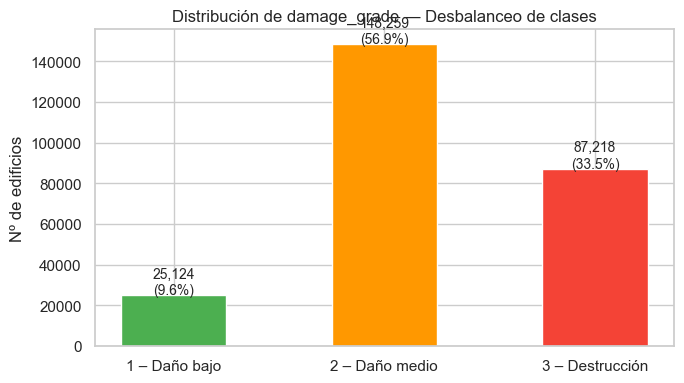

In [2]:
counts = train_labels['damage_grade'].value_counts().sort_index()
labels = ['1 – Daño bajo', '2 – Daño medio', '3 – Destrucción']
colors = ['#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(train_labels)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Distribución de damage_grade — Desbalanceo de clases')
ax.set_ylabel('Nº de edificios')
plt.tight_layout()
plt.show()

### 3.2 Variables numéricas clave por clase

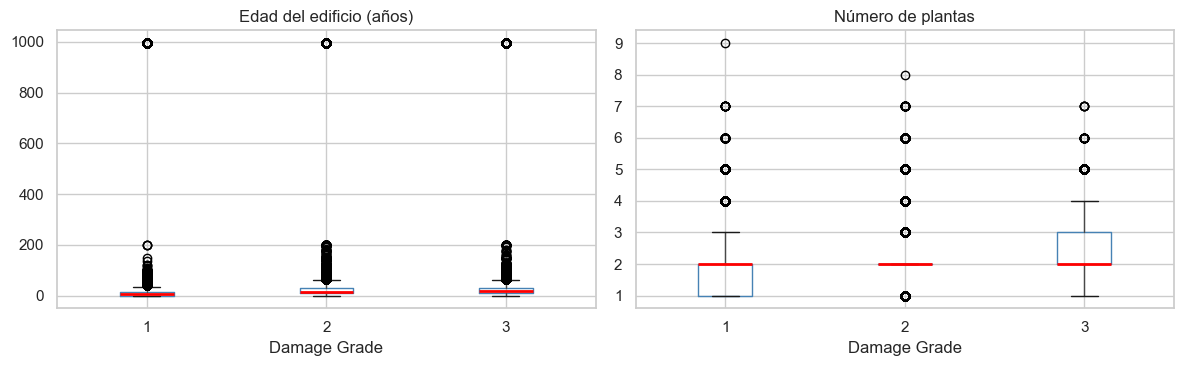

                age  count_floors_pre_eq
damage_grade                            
1             17.32                 1.84
2             27.34                 2.13
3             27.82                 2.21


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                          ['age', 'count_floors_pre_eq'],
                          ['Edad del edificio (años)', 'Número de plantas']):
    df_eda.boxplot(column=col, by='damage_grade', ax=ax,
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
    ax.set_title(title)
    ax.set_xlabel('Damage Grade')
plt.suptitle('')
plt.tight_layout()
plt.show()
print(df_eda.groupby('damage_grade')[['age','count_floors_pre_eq']].mean().round(2))

### 3.3 Daño medio por región geográfica

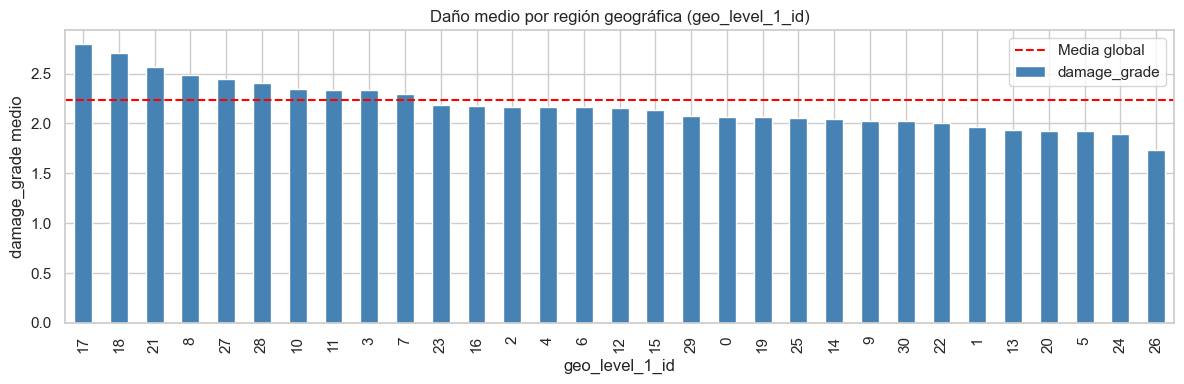

In [4]:
geo_damage = df_eda.groupby('geo_level_1_id')['damage_grade'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
geo_damage.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(df_eda['damage_grade'].mean(), color='red', linestyle='--', label='Media global')
ax.set_title('Daño medio por región geográfica (geo_level_1_id)')
ax.set_xlabel('geo_level_1_id')
ax.set_ylabel('damage_grade medio')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Preprocesado y Feature Engineering



In [5]:
def preprocess_and_engineer(X_train_df, X_test_df):
    for df in [X_train_df, X_test_df]:
        super_cols = [c for c in df.columns if c.startswith('has_superstructure')]
        sec_cols   = [c for c in df.columns if c.startswith('has_secondary_use')]
        df['total_superstructure_types'] = df[super_cols].sum(axis=1)
        df['total_secondary_uses']       = df[sec_cols].sum(axis=1)

    categorical_cols = X_train_df.select_dtypes(include=['object']).columns.tolist()
    X_train_enc = pd.get_dummies(X_train_df, columns=categorical_cols, drop_first=True)
    X_test_enc  = pd.get_dummies(X_test_df,  columns=categorical_cols, drop_first=True)
    X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
    return X_train_enc, X_test_enc

X_encoded, X_test_encoded = preprocess_and_engineer(train_values.copy(), test_values.copy())
y = train_labels['damage_grade']

print(f"Total de features: {X_encoded.shape[1]}")

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,}")

Total de features: 62
Train: 208,480 | Val: 52,121


## 5. Modelado

### 5.1 Baseline — Árbol de Decisión 

In [6]:
dt = DecisionTreeClassifier(
    criterion='gini', max_depth=10,
    min_samples_leaf=20, class_weight='balanced',
    random_state=RANDOM_STATE
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
f1_dt = f1_score(y_val, y_pred_dt, average='micro')
print(f"Micro F1 — Decision Tree (baseline): {f1_dt:.4f}")
print(classification_report(y_val, y_pred_dt, target_names=['Grado 1','Grado 2','Grado 3']))

Micro F1 — Decision Tree (baseline): 0.6067
              precision    recall  f1-score   support

     Grado 1       0.36      0.81      0.50      5025
     Grado 2       0.75      0.51      0.61     29652
     Grado 3       0.60      0.71      0.65     17444

    accuracy                           0.61     52121
   macro avg       0.57      0.68      0.59     52121
weighted avg       0.66      0.61      0.61     52121



### 5.2 Random Forest

Entrenamos el mejor RF conocido (n=1000) 

In [7]:
print("Entrenando Random Forest con n_estimators=1000")
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
f1_rf = f1_score(y_val, y_pred_rf, average='micro')
print(f"Micro F1 — Random Forest n=1000: {f1_rf:.4f}")
print(classification_report(y_val, y_pred_rf, target_names=['Grado 1','Grado 2','Grado 3']))

Entrenando Random Forest con n_estimators=1000
Micro F1 — Random Forest n=1000: 0.7139
              precision    recall  f1-score   support

     Grado 1       0.64      0.46      0.54      5025
     Grado 2       0.72      0.83      0.77     29652
     Grado 3       0.72      0.59      0.65     17444

    accuracy                           0.71     52121
   macro avg       0.69      0.63      0.65     52121
weighted avg       0.71      0.71      0.71     52121



### 5.3 HistGradientBoostingClassifier + RandomizedSearchCV 

`HistGradientBoostingClassifier` implementa **Gradient Boosted Trees** con discretización por histogramas: en lugar de evaluar todos los posibles splits de cada feature, agrupa los valores en bins y busca el split óptimo entre bins. Esto reduce el tiempo de entrenamiento de ~60mn a ~5mn con 260.000 instancias.

Aplicamos `RandomizedSearchCV` para optimizar sus hiperparámetros con `n_jobs=1` en el search externo para evitar el error de RAM, mientras el modelo interno usa todos los cores.

In [8]:
param_dist_hgb = {
    'max_iter'        : [300, 500, 700],
    'learning_rate'   : [0.03, 0.05, 0.08, 0.1],
    'max_leaf_nodes'  : [31, 63, 127],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 0.5],
}

print("RandomizedSearchCV sobre HistGradientBoosting ")
rs_hgb = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist_hgb,
    n_iter=10,
    cv=3,
    scoring='f1_micro',
    random_state=RANDOM_STATE,
    n_jobs=1,      
    verbose=2
)
rs_hgb.fit(X_train, y_train)

best_hgb = rs_hgb.best_estimator_
y_pred_hgb = best_hgb.predict(X_val)
f1_hgb = f1_score(y_val, y_pred_hgb, average='micro')

print(f"\nMejores parámetros:")
for k, v in rs_hgb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMicro F1 — HGB Optimizado: {f1_hgb:.4f}")
print(classification_report(y_val, y_pred_hgb, target_names=['Grado 1','Grado 2','Grado 3']))

RandomizedSearchCV sobre HistGradientBoosting 
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=700, max_leaf_nodes=127, min_samples_leaf=10; total time=  45.2s
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=700, max_leaf_nodes=127, min_samples_leaf=10; total time=  44.9s
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=700, max_leaf_nodes=127, min_samples_leaf=10; total time=  40.4s
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=300, max_leaf_nodes=31, min_samples_leaf=10; total time=  13.9s
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=300, max_leaf_nodes=31, min_samples_leaf=10; total time=  13.5s
[CV] END l2_regularization=0.1, learning_rate=0.03, max_iter=300, max_leaf_nodes=31, min_samples_leaf=10; total time=  13.7s
[CV] END l2_regularization=0.1, learning_rate=0.05, max_iter=300, max_leaf_nodes=31, min_samples_leaf=30; total time=  12.7s
[CV] END l2_re

## 6. Comparación de modelos

Comparación de modelos (Micro F1 en validación)
  0.7445  |  HGB Optimizado
  0.7139  |  Random Forest n=1000
  0.6067  |  Decision Tree


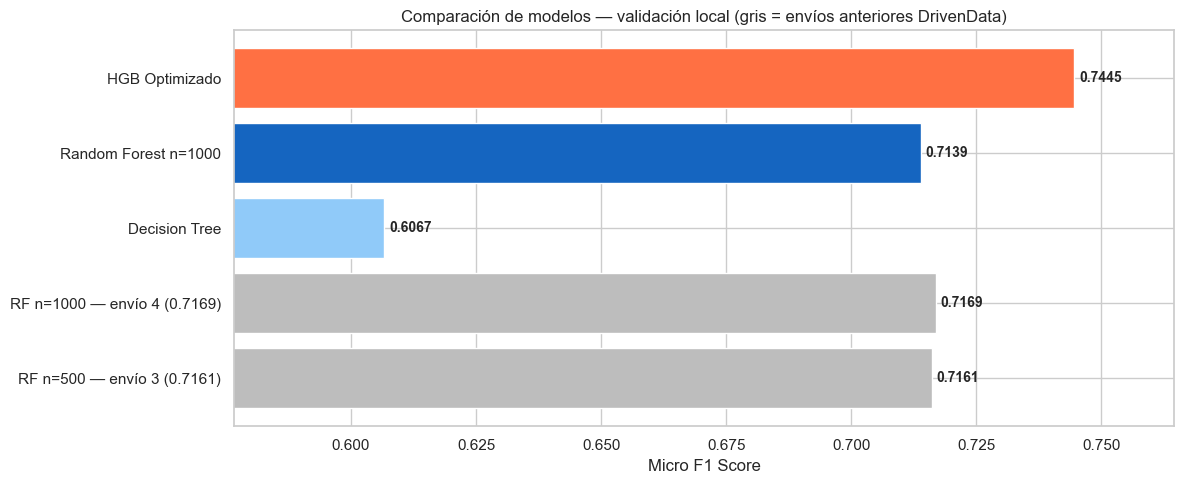

In [9]:
results = {
    'Decision Tree' : (f1_dt,  y_pred_dt),
    'Random Forest n=1000' : (f1_rf,  y_pred_rf),
    'HGB Optimizado' : (f1_hgb, y_pred_hgb),
}

anteriores = {
    'RF n=500 — envío 3 (0.7161)' : 0.7161,
    'RF n=1000 — envío 4 (0.7169)': 0.7169,
}

print("Comparación de modelos (Micro F1 en validación)")
for name, (score, _) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"  {score:.4f}  |  {name}")

all_names  = list(anteriores.keys()) + list(results.keys())
all_scores = list(anteriores.values()) + [v[0] for v in results.values()]
all_colors = ['#BDBDBD','#BDBDBD','#90CAF9','#1565C0','#FF7043']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(all_names, all_scores, color=all_colors, edgecolor='white')
for bar, val in zip(bars, all_scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(min(all_scores) - 0.03, max(all_scores) + 0.02)
ax.set_xlabel('Micro F1 Score')
ax.set_title('Comparación de modelos — validación local (gris = envíos anteriores DrivenData)')
plt.tight_layout()
plt.show()

## 7. Matrices de confusión del mejor modelo

Mejor modelo: HGB Optimizado — F1=0.7445


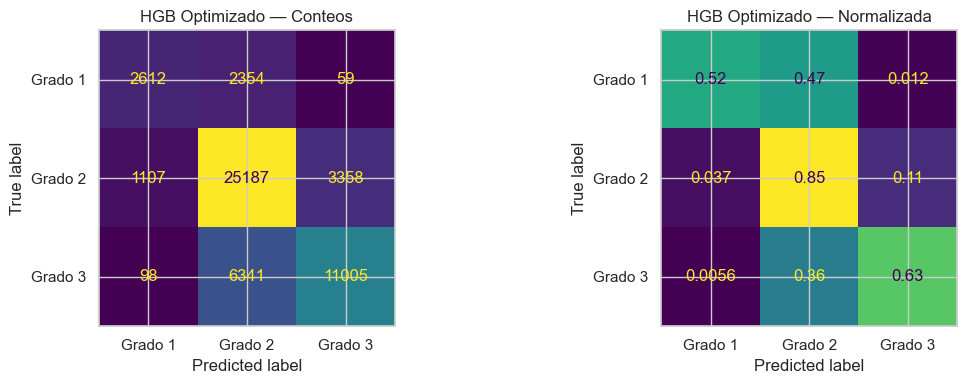

In [10]:
best_name  = max(results, key=lambda k: results[k][0])
best_score, y_pred_best = results[best_name]
print(f"Mejor modelo: {best_name} — F1={best_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, normalize, title in zip(axes,
                                [None, 'true'],
                                [f'{best_name} — Conteos',
                                 f'{best_name} — Normalizada']):
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred_best,
        display_labels=['Grado 1','Grado 2','Grado 3'],
        normalize=normalize, ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 8. Importancia de features (Random Forest)

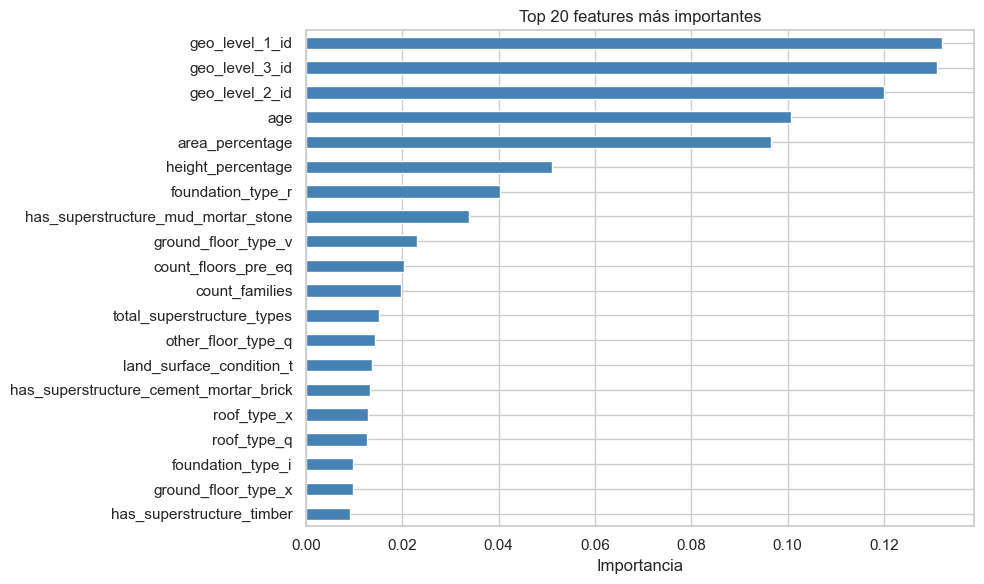

Top 5: geo_level_1_id     0.132079
geo_level_3_id     0.131103
geo_level_2_id     0.120051
age                0.100758
area_percentage    0.096646


In [11]:
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 features más importantes')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()
print("Top 5:", top20.head().to_string())

## 9. Generación del archivo de envío

Reentrenamos el mejor modelo con el **100% de los datos** de entrenamiento.

In [12]:
print(f"Reentrenando '{best_name}' con el 100% de los datos para predicción final")

if 'HGB' in best_name:
    final_model = HistGradientBoostingClassifier(
        **rs_hgb.best_params_,
        random_state=RANDOM_STATE
    )
else:
    final_model = RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_leaf=1,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    )

final_model.fit(X_encoded, y)
test_preds = final_model.predict(X_test_encoded)

submission = submission_format.copy()
submission['damage_grade'] = test_preds.astype(int)
submission.to_csv('P3_submission.csv')

print("\nArchivo 'P3_submission.csv' generado con éxito.")
print(f"Distribución de predicciones:\n{submission['damage_grade'].value_counts().sort_index()}")

Reentrenando 'HGB Optimizado' con el 100% de los datos para predicción final

Archivo 'P3_submission.csv' generado con éxito.
Distribución de predicciones:
damage_grade
1     6151
2    56818
3    23899
Name: count, dtype: int64


## Conclusiones

El proceso de experimentación con 4 envíos a DrivenData permitió 
identificar de forma empírica el modelo óptimo para este problema:

- **Envíos 1 y 2 (RF n=500 y n=1000):** el Random Forest estableció 
  un baseline sólido de F1=0.7169. Aumentar el número de árboles 
  de 500 a 1000 apenas mejoró el resultado (+0.0008), indicando que 
  el modelo había alcanzado su techo con esta configuración.

- **Envío 3 (GradientBoostingClassifier lr=0.05, n=500):** el GB 
  clásico resultó inferior al RF (F1=0.7150) a pesar de su mayor 
  coste computacional ~60mn. El entrenamiento secuencial sin 
  optimización de histogramas no compensó frente al Bagging paralelo.

- **Envío 4 (HistGradientBoostingClassifier + RandomizedSearchCV):** 
  modelo ganador con F1=**0.7422** en DrivenData, un salto de 
  **+0.025** sobre el mejor RF. La combinación de Boosting eficiente 
  con histogramas y la optimización de hiperparámetros mediante 
  `RandomizedSearchCV`  demostró ser la estrategia más 
  efectiva para este dataset de 260.000 instancias.